# $$\mathbb{E}[r_a] = r_f + \beta_a(\mathbb{E}[r_m] - r_f)$$ THE CAP model, captial asset pricing model
in which 

$$\beta_a = \frac{Cov(r_a, r_m)}{Var(r_m)}$$

in which $\mathbb{E}[r_a]$ is the expected return of investment, it may be a single stock or a portfoliom and if it is a portfolio then one can have it with $$\beta_a = w_1 \beta_1 + ... + w_n \beta_n$$

using Linear Regression in this case.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

#constants
RISK_FREE_RATE = 0.04
MONTHS_IN_YEAR = 12


In [2]:
class CAPM:
    def __init__(self, stocks, start_date, end_date):
        self.data = None
        self.stocks = stocks
        self.start_date = start_date
        self.end_date = end_date
        
    def download_data(self):
        
        data = {}
        
        for stock in self.stocks:
            ticker = yf.Ticker(stock)
            data[stock] = ticker.history(start = self.start_date, end = self.end_date)['Close'] #adjusted closing prices is a more reflection of the stock value.
        
        return pd.DataFrame(data)
    
    def initialize(self):
        stock_data = self.download_data()
        stock_data = stock_data.resample('ME').last()
        
        self.data = pd.DataFrame({'s_close' : stock_data[self.stocks[0]],
                                  'm_close' : stock_data[self.stocks[1]]})
        
        self.data[['s_return', 'm_return']] = np.log(self.data[['s_close', 'm_close']] / self.data[['s_close', 'm_close']].shift(1))
        
        self.data = self.data[1:]
        
        print(self.data)
        
        return self.data
        
    def calculate_beta(self):
        #b_a = cov(ra, rm)/var rm
        
        #data = self.initialize()
        #covariance_matrix = data.cov() 
        
        covariance_matrix = np.cov(self.data['s_return'], self.data['m_return'])
        
        beta = covariance_matrix[0, 1] / covariance_matrix[1,1]
        
        # var_1  cov_12
        # cov_12 var_2 
        # 2 as the market data and 1 as the return data 
        
        print(beta) 
        

    def plot_regression(self, alpha, beta):
        fig, axis = plt.subplots(1, figsize = (20,10))
        axis.scatter(self.data["m_return"], self.data["s_return"], label = "Data Points")
        axis.plot(self.data["m_return"], beta * self.data["m_return"] + alpha, color="r", label= "CAPM line") #the regression line
        plt.title("Capital Asset Pricing Model")
        plt.xlabel("Market Return $R_m$", fontsize = 18)
        plt.ylabel("Stock return $R_a$")
        plt.text(0.08, 0.05, "E[R] - Rf = α + β(E[Rm] - Rf)")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        
    #Era - rf = a + b(Erm - rf)
    def regression_method(self):
        #using linear regression to fit a line into a data
        
        beta, alpha = np.polyfit(self.data["m_return"], self.data["s_return"], deg = 1) #an alternative of using linear regression with different degree of the polynomial degree of the regression if linear -> it would be 1
        print("beta", beta, "alpha", alpha)
        
        expected_return = RISK_FREE_RATE + beta * (self.data['m_return'].mean() * MONTHS_IN_YEAR - RISK_FREE_RATE)
        print("Expected return E[r_a]", expected_return)
        self.plot_regression(alpha, beta)
        

                              s_close      m_close  s_return  m_return
Date                                                                  
2010-01-31 00:00:00-05:00   66.474846  1073.869995 -0.067221 -0.037675
2010-02-28 00:00:00-05:00   69.374542  1104.489990  0.042696  0.028115
2010-03-31 00:00:00-04:00   69.969193  1169.430054  0.008535  0.057133
2010-04-30 00:00:00-04:00   70.378410  1186.689941  0.005832  0.014651
2010-05-31 00:00:00-04:00   68.688248  1089.410034 -0.024308 -0.085532
...                               ...          ...       ...       ...
2016-08-31 00:00:00-04:00  100.875443  2170.949951 -0.002292 -0.001220
2016-09-30 00:00:00-04:00  100.856354  2168.270020 -0.000189 -0.001235
2016-10-31 00:00:00-04:00   97.580193  2126.149902 -0.033023 -0.019617
2016-11-30 00:00:00-05:00  103.930405  2198.810059  0.063047  0.033604
2016-12-31 00:00:00-05:00  106.345772  2238.830078  0.022974  0.018037

[84 rows x 4 columns]
0.7301119945789621
beta 0.7301119945789618 alpha -0.00

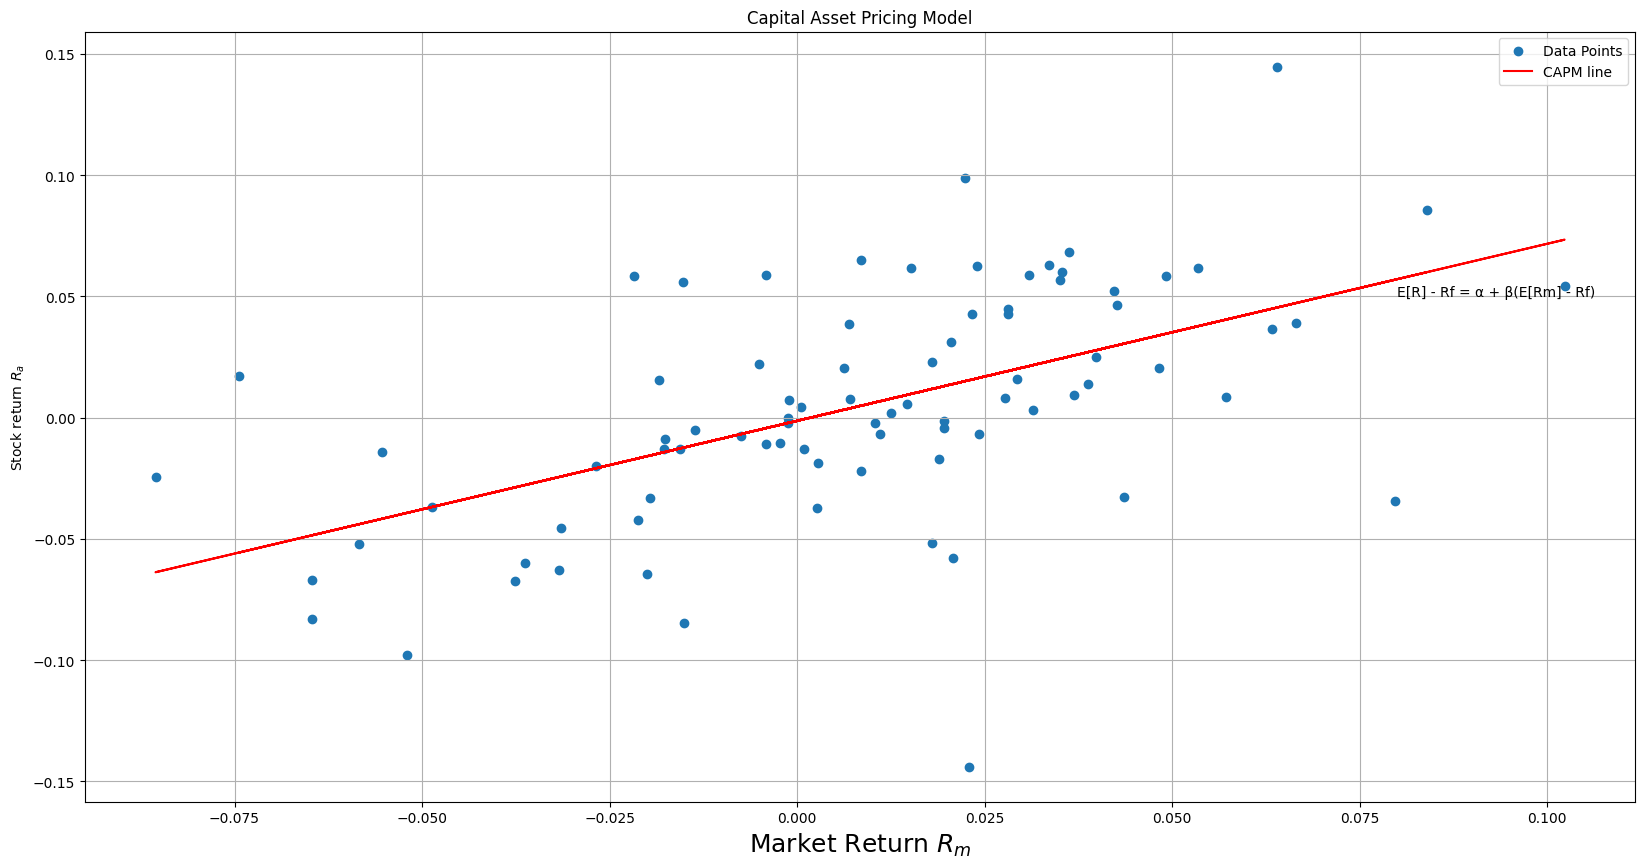

$I: possibly delisted; no timezone found


AttributeError: 'CAPM' object has no attribute 'normal_dis'

In [3]:
if __name__ == "__main__":
    capm = CAPM(['IBM', '^GSPC'], '2009-12-30', '2017-01-01')
    capm.initialize()
    capm.calculate_beta()
    capm.regression_method()
    
    capm2 = CAPM('IBM', '2009-12-30', '2017-01-01')
    capm2.download_data()
    capm2.normal_dis(capm2.calculate_return)

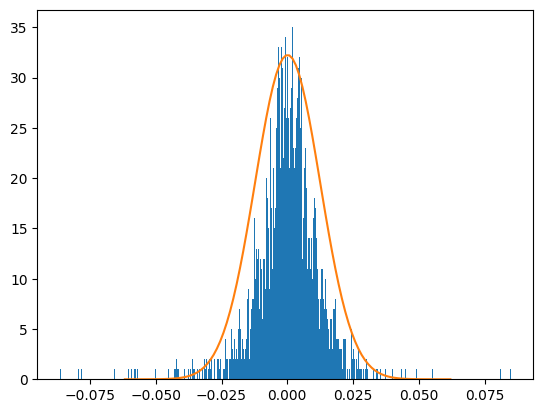

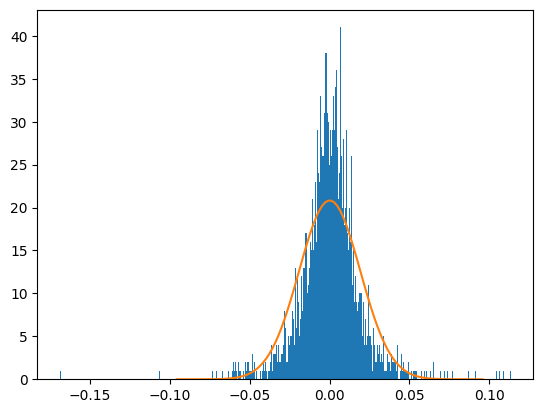

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm


def download_data(stock, start_date, end_date):
    data = {}
    ticker = yf.Ticker(stock)
    data['Price'] = ticker.history(start = start_date, end = end_date)['Close'] 
    return pd.DataFrame(data)


def calculate_returns(stock_data):
    stock_data['Price'] = np.log(stock_data['Price'] / stock_data['Price'].shift(1))
    return stock_data[1:]


def show_plot(stock_data):
    plt.hist(stock_data, bins=700)
    stock_variance = stock_data.var()
    stock_mean = stock_data.mean()
    sigma = np.sqrt(stock_variance)
    x = np.linspace(stock_mean - 5 * sigma, stock_mean + 5 * sigma, 100)
    plt.plot(x, norm.pdf(x, stock_mean, sigma))
    plt.show()


if __name__ == "__main__":
    stock = download_data('IBM', '2010-01-01', '2020-01-01')
    log_daily_returns = calculate_returns(stock)
    show_plot(log_daily_returns)
    
    stock = download_data('IBM', '2000-01-01', '2010-01-01')
    log_daily_returns = calculate_returns(stock)
    show_plot(log_daily_returns)
